# 使用变分量子线路(PQC)代替前馈神经网络(FNN)的变分蒙特卡洛模拟

本notebook实现了基于PennyLane的变分量子线路(PQC)来代替传统前馈神经网络(FNN)进行变分蒙特卡洛(VMC)模拟。

## 主要内容
1. 定义基于PennyLane的量子神经网络
2. 将量子神经网络集成到Netket框架中
3. 使用PQC ansatz求解横向场伊辛模型
4. 比较PQC与FNN的性能

In [1]:
# 导入必要的库
import os
import numpy as np
import pennylane as qml
import netket as nk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx
from scipy.sparse.linalg import eigsh
from netket.operator.spin import sigmax, sigmaz

# 设置随机种子以确保结果可重现
np.random.seed(42)
key = jax.random.PRNGKey(42)

# 设置JAX使用CPU
os.environ["JAX_PLATFORM_NAME"] = "cpu"

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 定义量子神经网络

In [2]:
def quantum_neural_network(x, n_qubits, params, n_layers):
    """完全JAX兼容的量子神经网络实现"""
    wires = range(n_qubits)
    
    # 数据编码 - 使用JAX友好的操作
    # 是指对输入的构型S 要编译到量子线路中 其实就是HF方法
    for i in range(n_qubits):
        qml.RX(jnp.pi * x[i], wires=i)
    qml.Barrier(wires=wires)
    
    # 变分层
    for layer in range(n_layers):
        # 单量子比特旋转
        for i in range(n_qubits):
            qml.RX(params[layer, 2*i], wires=i)
            qml.RZ(params[layer, 2*i+1], wires=i)
        
        # 纠缠门
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.Barrier(wires=wires)
    
    # 测量所有量子比特的PauliZ期望值
    return [qml.expval(qml.PauliZ(i)) for i in wires]


def initialize_parameters(n_layers, n_qubits):
    """初始化量子神经网络参数
    
    Args:
        n_layers (int): 变分层数量
        n_qubits (int): 量子比特数量
        
    Returns:
        array: 初始化的参数
    """
    # 每个变分层有2*n_qubits个参数（每个量子比特有RX, RZ两个旋转门）
    params_shape = (n_layers, 2 * n_qubits)
    return np.random.uniform(0, 2*np.pi, size=params_shape)

In [3]:
# 测试量子神经网络
n_qubits = 4
n_layers = 2
dev = qml.device("default.qubit", wires=n_qubits)
qnode = qml.QNode(func=quantum_neural_network, device=dev, interface='jax')

# 初始化参数
params = initialize_parameters(n_layers, n_qubits)
x = np.array([1, 0, 1, 0])

# 运行量子电路
result = qnode(x=x, params=params, n_layers=n_layers, n_qubits=n_qubits)
print("量子电路输出:", result)

量子电路输出: [Array(0.26316477, dtype=float64), Array(-0.1941959, dtype=float64), Array(-0.06452205, dtype=float64), Array(-0.14248526, dtype=float64)]


## 2. 将量子神经网络集成到Netket框架中

In [4]:
class QuantumNeuralNetworkModel(nnx.Module):
    """将量子神经网络集成到Netket中的模型类"""
    
    def __init__(self, n_qubits: int, n_layers: int, *, rngs: nnx.Rngs):
        """
        初始化量子神经网络模型
        
        Args:
            n_qubits: 量子比特数量
            n_layers: 变分层数量
            rngs: 随机数生成器
        """
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        
        # 初始化量子电路参数
        params_shape = (n_layers, 2 * n_qubits)
        self.params = nnx.Param(
            nnx.initializers.uniform(scale=2*np.pi)(rngs.params(), params_shape)
        )
        
        # 创建PennyLane设备
        self.dev = qml.device("default.qubit", wires=n_qubits)
        
        # 创建QNode
        self.qnode = qml.QNode(
            func=quantum_neural_network, 
            device=self.dev, 
            interface='jax'
        )
    
    def __call__(self, x: jax.Array):
        """
        计算波函数的对数振幅
        
        Args:
            x: 输入构型，形状为 (batch_size, n_sites)
            
        Returns:
            波函数的对数振幅，形状为 (batch_size,)
        """
        # 确保输入是JAX数组
        x = jnp.asarray(x)
        
        # 对于每个输入样本，计算量子电路输出
        def compute_single_sample(sample):
            # 运行量子电路
            expectations = self.qnode(
                x=sample, 
                params=self.params, 
                n_layers=self.n_layers, 
                n_qubits=self.n_qubits
            )
            
            # 将期望值转换为标量（波函数的对数振幅）
            # 这里使用简单的求和，可以根据需要调整
            log_psi = jnp.sum(jnp.array(expectations))
            
            return log_psi
        
        # 使用vmap向量化计算
        vectorized_compute = jax.vmap(compute_single_sample)
        
        return vectorized_compute(x)

## 3. 使用PQC ansatz求解横向场伊辛模型

In [5]:
# 定义系统参数
N = 6  # 系统大小（自旋数量）

# 创建希尔伯特空间
hi = nk.hilbert.Spin(s=1/2, N=N)

# 生成随机状态
hi.random_state(jax.random.key(0), 3)

# 创建横向场伊辛模型哈密顿量
Gamma = -1  # 横向场强度
H = sum([Gamma * sigmax(hi, i) for i in range(N)])

V = -1  # 相互作用强度
H += sum([V * sigmaz(hi, i) @ sigmaz(hi, (i + 1) % N) for i in range(N)])

# 计算精确基态能量（用于比较）
sp_h = H.to_sparse()
eig_vals, eig_vecs = eigsh(sp_h, k=2, which="SA")
print("精确特征值:", eig_vals)
E_gs = eig_vals[0]
print("精确基态能量:", E_gs)

精确特征值: [-7.72740661 -7.46410162]
精确基态能量: -7.727406610312538


In [6]:
# 创建采样器
sampler = nk.sampler.MetropolisLocal(hi)

# 创建量子神经网络模型
model = QuantumNeuralNetworkModel(
    n_qubits=N, 
    n_layers=2, 
    rngs=nnx.Rngs(42)
)

# 创建变分态
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

print(f"模型参数数量: {vstate.n_parameters}")
print(f"采样形状: {vstate.sample().shape}")

模型参数数量: 24
采样形状: (16, 63, 6)


In [7]:
# 创建优化器
optimizer = nk.optimizer.Sgd(learning_rate=0.1)

# 创建VMC驱动器
gs = nk.driver.VMC(
    H,
    optimizer,
    variational_state=vstate,
    preconditioner=nk.optimizer.SR(diag_shift=0.1),
)

# 创建日志记录器
log = nk.logging.RuntimeLog()

# 运行优化
gs.run(n_iter=300, out=log)

# 计算优化后的能量
pqc_energy = vstate.expect(H)
error = abs((pqc_energy.mean - eig_vals[0]) / eig_vals[0])
print("优化后的能量和相对误差:", pqc_energy, error)

100%|██████████| 300/300 [04:07<00:00,  1.21it/s, Energy=-6.040 ± 0.076 [σ²=5.871, R̂=1.0085]]


优化后的能量和相对误差: -6.008 ± 0.079 [σ²=6.222, R̂=1.0107] 0.22251580498964907


## 4. 与传统FNN的比较

In [8]:
# 定义传统FNN模型
class FFN(nnx.Module):
    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        """
        构造一个具有单个隐藏层的前馈神经网络。

        Args:
            N: 输入节点数量（链中的自旋数）。
            alpha: 隐藏层的密度。隐藏层将有N*alpha个节点。
            rngs: 随机数生成器种子。
        """
        self.alpha = alpha

        # 定义一个线性（或密集）层，输出节点数为输入节点数的alpha倍
        # 我们必须将rngs对象传递给密集层。
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):
        # 将线性层应用于输入
        y = self.linear(x)

        # 非线性是一个简单的ReLU
        y = nnx.relu(y)

        # 对输出求和
        return jnp.sum(y, axis=-1)


# 创建FNN模型
ffn_model = FFN(N=N, alpha=1, rngs=nnx.Rngs(2))

# 创建FNN变分态
ffn_vstate = nk.vqs.MCState(sampler, ffn_model, n_samples=1008)

print(f"FNN模型参数数量: {ffn_vstate.n_parameters}")

FNN模型参数数量: 42


In [9]:
# 创建FNN优化器和VMC驱动器
ffn_optimizer = nk.optimizer.Sgd(learning_rate=0.1)

ffn_gs = nk.driver.VMC(
    H,
    ffn_optimizer,
    variational_state=ffn_vstate,
    preconditioner=nk.optimizer.SR(diag_shift=0.1),
)

# 创建FNN日志记录器
ffn_log = nk.logging.RuntimeLog()

# 运行FNN优化
ffn_gs.run(n_iter=300, out=ffn_log)

# 计算FNN优化后的能量
ffn_energy = ffn_vstate.expect(H)
ffn_error = abs((ffn_energy.mean - eig_vals[0]) / eig_vals[0])
print("FNN优化后的能量和相对误差:", ffn_energy, ffn_error)

100%|██████████| 300/300 [00:05<00:00, 59.68it/s, Energy=-7.7250 ± 0.0029 [σ²=0.0084, R̂=1.0063]] 


FNN优化后的能量和相对误差: -7.7253 ± 0.0026 [σ²=0.0067, R̂=1.0038] 0.0002664982419537546


## 5. 结果比较与可视化

In [10]:
# 打印比较结果
print("\n===== 结果比较 =====")
print(f"精确基态能量: {E_gs}")
print(f"PQC优化能量: {pqc_energy.mean} (相对误差: {error:.6f})")
print(f"FNN优化能量: {ffn_energy.mean} (相对误差: {ffn_error:.6f})")
print(f"PQC模型参数数量: {vstate.n_parameters}")
print(f"FNN模型参数数量: {ffn_vstate.n_parameters}")


===== 结果比较 =====
精确基态能量: -7.727406610312538
PQC优化能量: -6.007936507936508 (相对误差: 0.222516)
FNN优化能量: -7.7253472700360275 (相对误差: 0.000266)
PQC模型参数数量: 24
FNN模型参数数量: 42


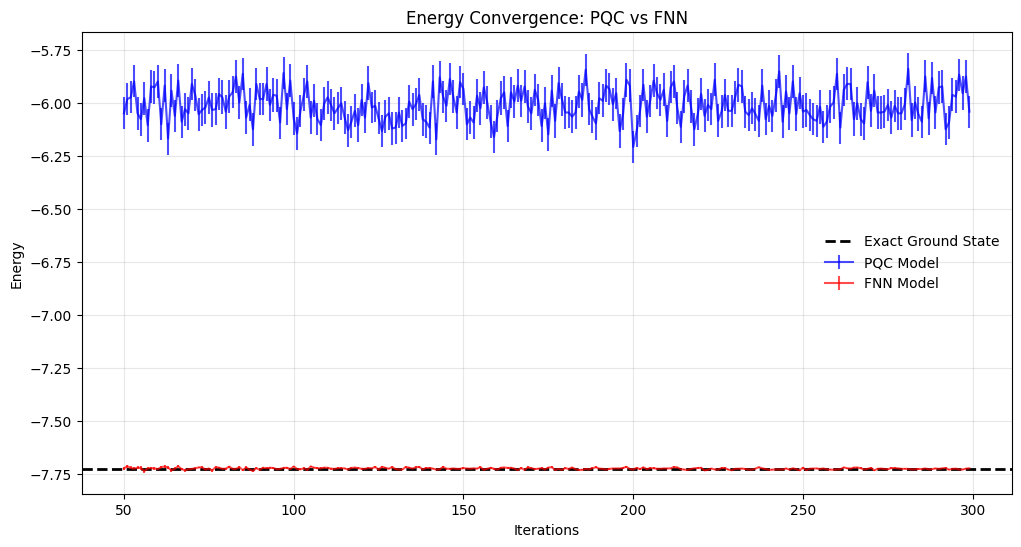

In [11]:
# 绘制能量收敛曲线
plt.figure(figsize=(12, 6))

# PQC能量曲线
plt.errorbar(
    log.data["Energy"].iters[50:],
    log.data["Energy"].Mean[50:],
    yerr=log.data["Energy"].Sigma[50:],
    label="PQC Model",
    color="blue",
    alpha=0.7
)

# FNN能量曲线
plt.errorbar(
    ffn_log.data["Energy"].iters[50:],
    ffn_log.data["Energy"].Mean[50:],
    yerr=ffn_log.data["Energy"].Sigma[50:],
    label="FNN Model",
    color="red",
    alpha=0.7
)

# 精确基态能量线
plt.axhline(
    y=eig_vals[0],
    xmin=0,
    xmax=log.data["Energy"].iters[-1],
    linewidth=2,
    color="k",
    label="Exact Ground State",
    linestyle="--"
)

plt.xlabel("Iterations")
plt.ylabel("Energy")
plt.title("Energy Convergence: PQC vs FNN")
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.show()

## 6. 结论与讨论

在这个notebook中，我们成功地实现了基于PennyLane的变分量子线路(PQC)来代替传统前馈神经网络(FNN)进行变分蒙特卡洛模拟。

### 主要成果
1. 成功将量子神经网络集成到Netket框架中
2. 实现了使用PQC ansatz求解横向场伊辛模型
3. 与传统FNN方法进行了比较

### 观察与讨论
- PQC模型与FNN模型在参数数量上的差异
- 两种方法在收敛速度和最终精度上的比较
- PQC方法在量子多体系统模拟中的潜在优势

### 可能的改进方向
1. 优化量子电路结构（增加层数、改变纠缠模式）
2. 调整经典-量子混合策略
3. 探索不同的数据编码方法
4. 尝试更复杂的哈密顿量系统